<a href="https://colab.research.google.com/github/UleleBulele/ML-Analysis-of-Video-Games/blob/main/Report_Project_Group_B06C_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [2]:
df_raw = pd.read_csv('/content/drive/MyDrive/VideoGames.csv')
df_raw.head()

,Name,Platform,Year_of_Release,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score
0,SSX Tricky,GC,2001,Sports,0.42,0.11,0.00,0.01,0.54,87.0,8.6
1,Chaos Legion,PS2,2003,Action,0.15,0.12,0.00,0.04,0.30,65.0,8.2
2,RIGS: Mechanized Combat League,PS4,2016,Action,0.03,0.05,0.01,0.02,0.11,79.0,7.9
3,Sorcery,PS3,2012,Action,0.14,0.11,0.00,0.05,0.29,70.0,7.3
4,Tokobot,PSP,2005,Platform,0.06,0.00,0.00,0.00,0.06,72.0,7.3


In [3]:
df_raw.describe().round(2)

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score
count,6250.00,6229.00,6236.00,6233.00,6236.00,6232.00,6231.00,6235.00
mean,2007.48,0.40,0.24,0.07,0.09,0.80,69.93,7.14
std,4.22,1.00,0.72,0.30,0.28,2.04,13.99,1.46
min,1985.00,0.00,0.00,0.00,0.00,0.01,13.00,0.50
25%,2004.00,0.06,0.02,0.00,0.01,0.11,61.00,6.40
50%,2007.00,0.15,0.06,0.00,0.02,0.29,72.00,7.50
75%,2011.00,0.39,0.21,0.01,0.07,0.75,80.00,8.20
max,2016.00,41.36,28.96,6.50,10.57,82.53,98.00,9.60


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6250 entries, 0 to 6249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6250 non-null   object 
 1   Platform         6250 non-null   object 
 2   Year_of_Release  6250 non-null   int64  
 3   Genre            6250 non-null   object 
 4   NA_Sales         6229 non-null   float64
 5   EU_Sales         6236 non-null   float64
 6   JP_Sales         6233 non-null   float64
 7   Other_Sales      6236 non-null   float64
 8   Global_Sales     6232 non-null   float64
 9   Critic_Score     6231 non-null   float64
 10  User_Score       6235 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 537.2+ KB


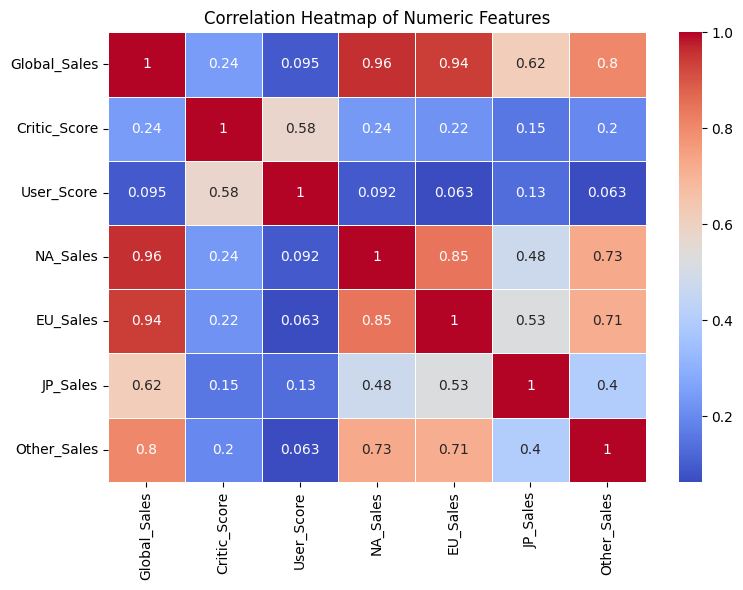

In [5]:
df_vis = df_raw.copy()

df_vis['User_Score'] = pd.to_numeric(df_vis['User_Score'], errors='coerce')
df_vis['Year_of_Release'] = pd.to_numeric(df_vis['Year_of_Release'], errors='coerce')

# Select relevant numeric columns
heatmap_cols = ['Global_Sales', 'Critic_Score', 'User_Score',
                'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Drop rows with missing values in those columns
df_heat = df_vis[heatmap_cols].dropna()

# Compute and plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_heat.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

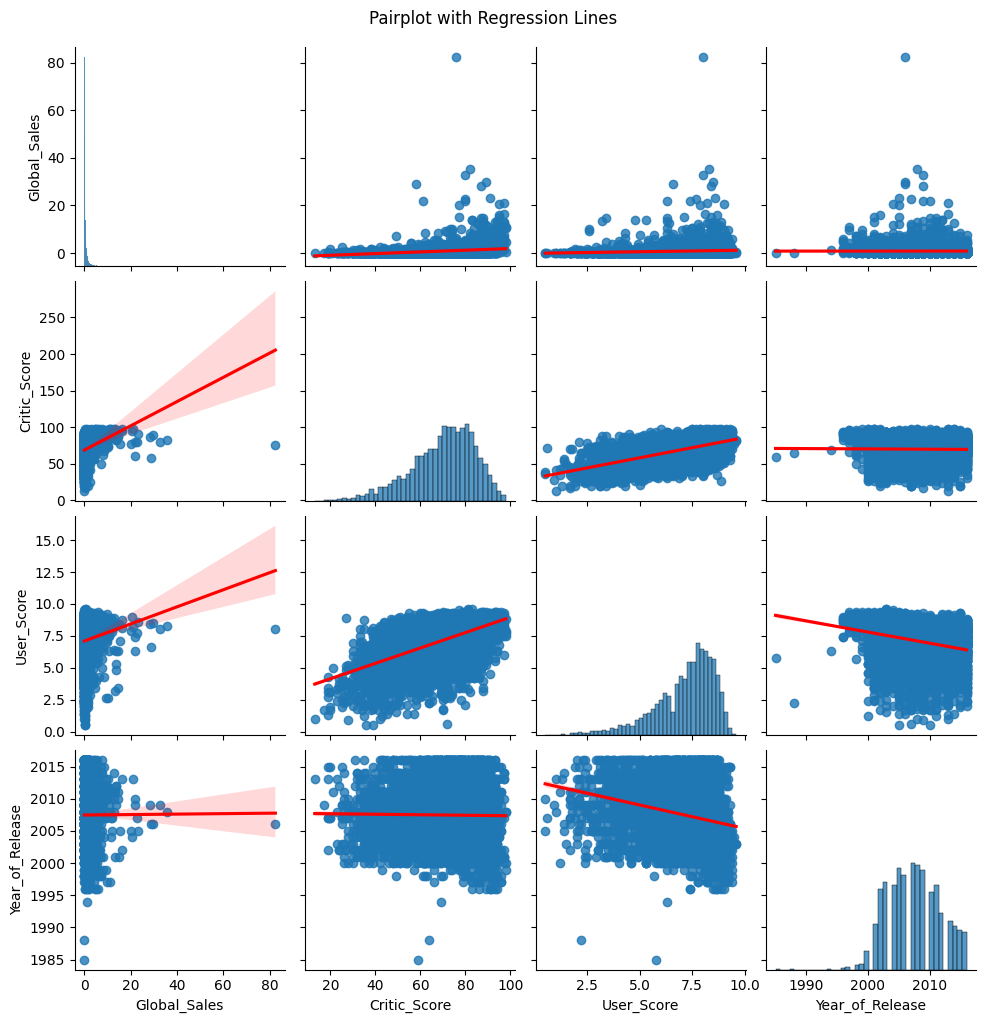

In [6]:
pairplot_cols = ['Global_Sales', 'Critic_Score', 'User_Score', 'Year_of_Release']

# Drop missing values for selected columns
df_pair = df_vis[pairplot_cols].dropna()

# Create the pairplot
sns.pairplot(df_pair, kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle('Pairplot with Regression Lines', y=1.02)
plt.show()

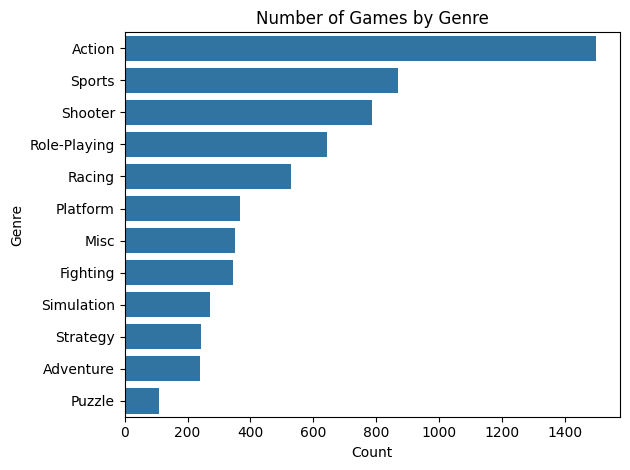

In [7]:
df_genre = df_vis.dropna(subset=['Genre'])

sns.countplot(data=df_genre, y='Genre', order=df_genre['Genre'].value_counts().index)
plt.title('Number of Games by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [8]:
print(df_raw.isnull().sum())
print('\n', df_raw.shape)

Name                0
Platform            0
Year_of_Release     0
Genre               0
NA_Sales           21
EU_Sales           14
JP_Sales           17
Other_Sales        14
Global_Sales       18
Critic_Score       19
User_Score         15
dtype: int64

 (6250, 11)


In [9]:
df = df_raw.dropna()
print(df.isnull().sum())
print('\n', df.shape)

Name               0
Platform           0
Year_of_Release    0
Genre              0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
User_Score         0
dtype: int64

 (6142, 11)


In [10]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[['Genre', 'Platform']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Genre', 'Platform']))
df_encoded = df.drop(columns=['Genre', 'Platform']).reset_index(drop=True)
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
df_encoded = df_encoded.drop(columns=['Name'])
df_encoded.head()


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score,Genre_Adventure,Genre_Fighting,...,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,2001,0.42,0.11,0.00,0.01,0.54,87.0,8.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2003,0.15,0.12,0.00,0.04,0.30,65.0,8.2,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2016,0.03,0.05,0.01,0.02,0.11,79.0,7.9,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012,0.14,0.11,0.00,0.05,0.29,70.0,7.3,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2005,0.06,0.00,0.00,0.00,0.06,72.0,7.3,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = ['Critic_Score', 'User_Score', 'Year_of_Release']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_final = df_encoded.copy()
df_final.head()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score,Genre_Adventure,Genre_Fighting,...,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,-1.533781,0.42,0.11,0.00,0.01,0.54,1.221452,0.998854,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.059711,0.15,0.12,0.00,0.04,0.30,-0.353669,0.724503,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.021745,0.03,0.05,0.01,0.02,0.11,0.648681,0.518740,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.073604,0.14,0.11,0.00,0.05,0.29,0.004313,0.107214,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.585641,0.06,0.00,0.00,0.00,0.06,0.147506,0.107214,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df_final.drop(columns=['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])
y = df_final['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R² Score: 0.135
RMSE: 1.447


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df_final['Popular'] = (df_final['Global_Sales'] >= 1).astype(int)

X = df_final.drop(columns=['Global_Sales', 'Popular', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])
y = df_final['Popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[715 272]
 [ 60 182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81       987
           1       0.40      0.75      0.52       242

    accuracy                           0.73      1229
   macro avg       0.66      0.74      0.67      1229
weighted avg       0.82      0.73      0.75      1229



In [14]:
from sklearn.preprocessing import StandardScaler

cluster_cols = ['Critic_Score', 'User_Score', 'Global_Sales']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_final[cluster_cols])


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
features = ['Critic_Score', 'User_Score', 'Global_Sales']
df_final = df[features].dropna()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_final)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df_final['Cluster'] = clusters

sil_score = silhouette_score(scaled_features, clusters)
print(f"Silhouette Score for 3 clusters: {sil_score:.4f}")

Silhouette Score for 3 clusters: 0.2976


In [16]:
cluster_summary = df_final.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         Critic_Score  User_Score  Global_Sales
Cluster                                        
0               51.01        4.82          0.34
1               66.81        7.23          0.38
2               82.57        8.14          1.52


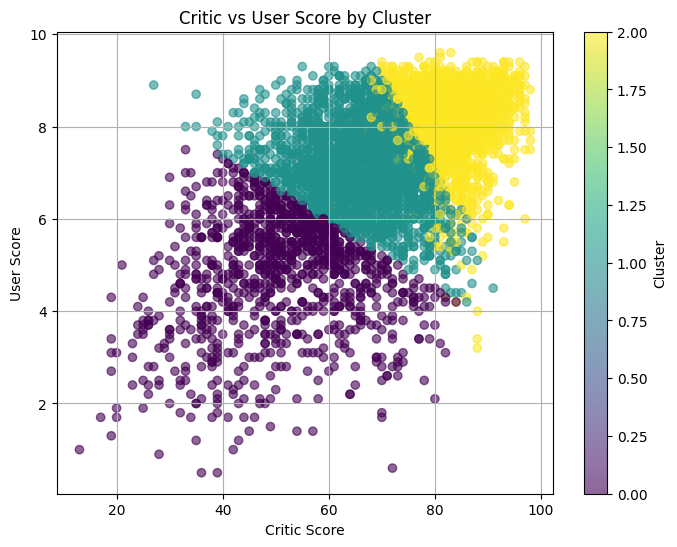

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_final['Critic_Score'], df_final['User_Score'], c=df_final['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Critic Score')
plt.ylabel('User Score')
plt.title('Critic vs User Score by Cluster')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

